In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

import os
from pathlib import Path
import sys
# Set sys path
sys.path.append(str(Path(os.getcwd()).parent))

# Set filpaths for data and figures
notebook_dir = os.getcwd()
file_path = Path(notebook_dir).parent / 'data' 

In [15]:
plt.rcParams['pdf.fonttype'] = 42  # Use Type 3 (PostScript) fonts
plt.rcParams['ps.fonttype'] = 42

In [16]:
file_path

PosixPath('/Users/jbmr/Notebooks/data_viz/data')

In [17]:
df = pd.read_csv(file_path / "logitudinal_data_example_dummy_data.csv", sep=',')

In [18]:
df

,individual,timepoint,value
0,A,1,4.394788
1,A,2,3.362785
2,A,3,2.162105
3,A,4,0.393175
4,A,5,0.571002
5,A,6,0.217951
6,A,7,4.031804
7,A,8,1.013601
8,A,9,2.540427
9,A,10,0.531322


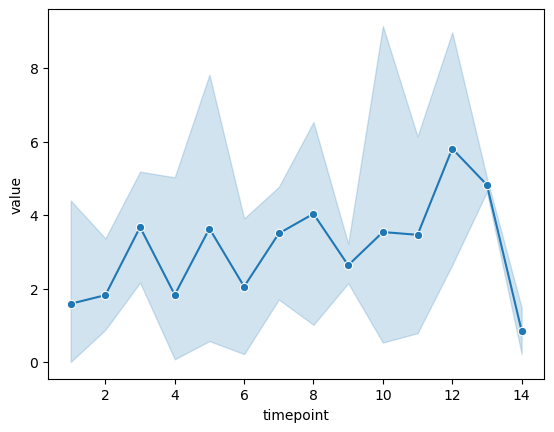

In [19]:
sns.lineplot(data=df, x='timepoint', y='value', marker='o')
plt.show()

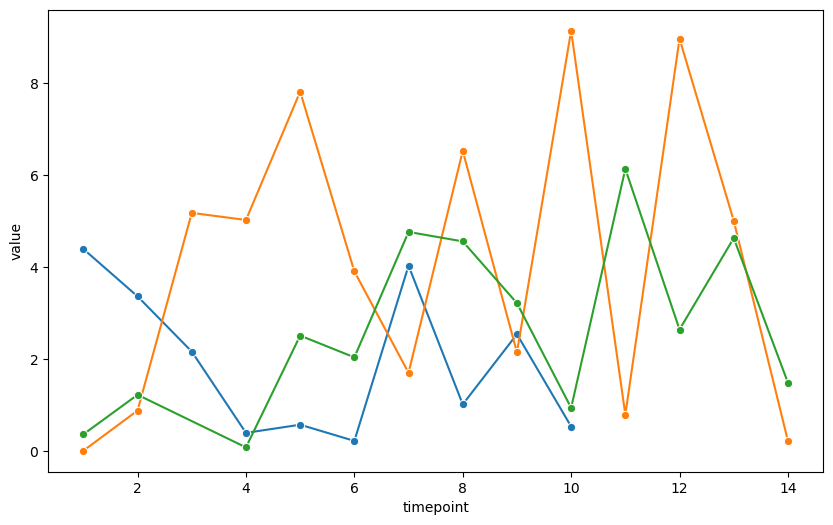

In [20]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='timepoint', y='value', hue='individual', marker='o', legend=False)
plt.show()

# lets create some more elaborate dummy data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Define parameters
n_groups = 3
n_patients_per_group = 5
timepoints = [0, 1, 2, 3, 6, 9, 12]  # months
groups = ['Control', 'Treatment A', 'Treatment B']

# Create empty list to store data
data = []

# Generate data for each group
for group_idx, group in enumerate(groups):
    for patient in range(n_patients_per_group):
        patient_id = f"{group}_{patient+1}"
        
        # Define different trajectory patterns for each group
        if group == 'Control':
            # Stable with slight random variation
            baseline = 50 + np.random.normal(0, 5)
            trajectory = baseline + np.random.normal(0, 3, len(timepoints))
            
        elif group == 'Treatment A':
            # Improving over time
            baseline = 45 + np.random.normal(0, 5)
            improvement_rate = np.random.uniform(1.5, 3)
            trajectory = baseline + improvement_rate * np.array(timepoints) + np.random.normal(0, 2, len(timepoints))
            
        else:  # Treatment B
            # Initial improvement then plateau
            baseline = 48 + np.random.normal(0, 5)
            trajectory = baseline + 15 * (1 - np.exp(-0.5 * np.array(timepoints))) + np.random.normal(0, 2.5, len(timepoints))
        
        # Add individual patient variation
        trajectory += np.random.normal(0, 2, len(timepoints))
        
        # Create records for each timepoint
        for t, value in zip(timepoints, trajectory):
            data.append({
                'patient_id': patient_id,
                'group': group,
                'timepoint': t,
                'value': value
            })

# Create DataFrame
df = pd.DataFrame(data)

# Save to CSV
#df.to_csv(file_path / 'dummy_longitudinal_data.csv', index=False)
print("Data saved to 'dummy_longitudinal_data.csv'")

# Display sample of data
print("\nData sample:")
print(df.head(10))
print(f"\nTotal records: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")



Data saved to 'dummy_longitudinal_data.csv'

Data sample:
  patient_id    group  timepoint      value
0  Control_1  Control          0  51.129829
1  Control_1  Control          1  55.511756
2  Control_1  Control          2  56.125825
3  Control_1  Control          3  50.849651
4  Control_1  Control          6  52.265084
5  Control_1  Control          9  53.394649
6  Control_1  Control         12  51.336039
7  Control_2  Control          0  41.300573
8  Control_2  Control          1  47.042539
9  Control_2  Control          2  44.686335

Total records: 105
Unique patients: 15


In [22]:
df

,patient_id,group,timepoint,value
0,Control_1,Control,0,51.129829
1,Control_1,Control,1,55.511756
2,Control_1,Control,2,56.125825
3,Control_1,Control,3,50.849651
4,Control_1,Control,6,52.265084
...,...,...,...,...
100,Treatment B_5,Treatment B,2,57.949779
101,Treatment B_5,Treatment B,3,61.388052
102,Treatment B_5,Treatment B,6,64.764087
103,Treatment B_5,Treatment B,9,62.464439


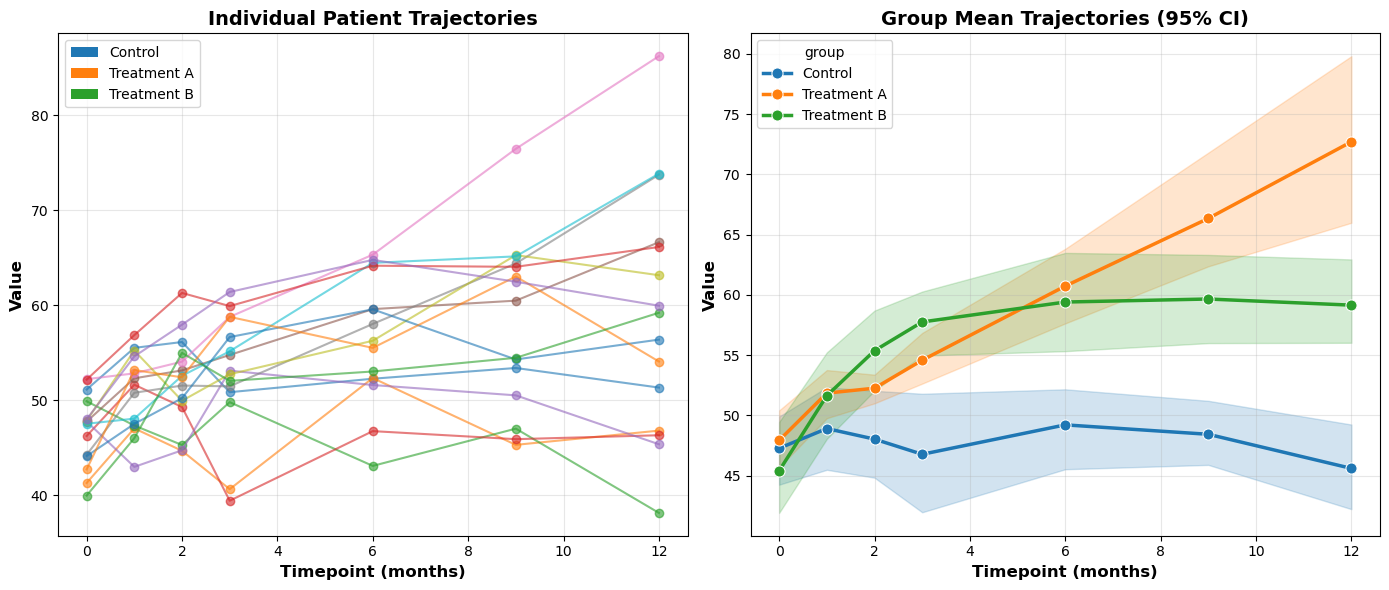


Summary by group and timepoint:
                        mean   std  count
group       timepoint                    
Control     0          47.27  3.83      5
            1          48.91  4.79      5
            2          48.03  4.92      5
            3          46.77  6.27      5
            6          49.21  4.13      5
            9          48.43  3.43      5
            12         45.60  4.75      5
Treatment A 0          47.93  2.83      5
            1          51.84  2.65      5
            2          52.25  1.58      5
            3          54.58  2.78      5
            6          60.73  3.98      5
            9          66.34  5.98      5
            12         72.70  8.84      5
Treatment B 0          45.40  4.76      5
            1          51.64  4.66      5
            2          55.37  4.39      5
            3          57.75  3.63      5
            6          59.40  5.18      5
            9          59.65  4.85      5
            12         59.14  4.55      5


In [23]:
# Plot the data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Individual trajectories colored by group
for group in groups:
    group_data = df[df['group'] == group]
    for patient in group_data['patient_id'].unique():
        patient_data = group_data[group_data['patient_id'] == patient]
        ax1.plot(patient_data['timepoint'], patient_data['value'], 
                marker='o', alpha=0.6, linewidth=1.5)

ax1.set_xlabel('Timepoint (months)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Value', fontsize=12, fontweight='bold')
ax1.set_title('Individual Patient Trajectories', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Create custom legend for groups
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=sns.color_palette()[i], label=group) 
                  for i, group in enumerate(groups)]
ax1.legend(handles=legend_elements, loc='best')

# Plot 2: Group means with confidence intervals
sns.lineplot(data=df, x='timepoint', y='value', hue='group', 
            marker='o', markersize=8, linewidth=2.5, ax=ax2)
ax2.set_xlabel('Timepoint (months)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Value', fontsize=12, fontweight='bold')
ax2.set_title('Group Mean Trajectories (95% CI)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary by group and timepoint:")
summary = df.groupby(['group', 'timepoint'])['value'].agg(['mean', 'std', 'count'])
print(summary.round(2))

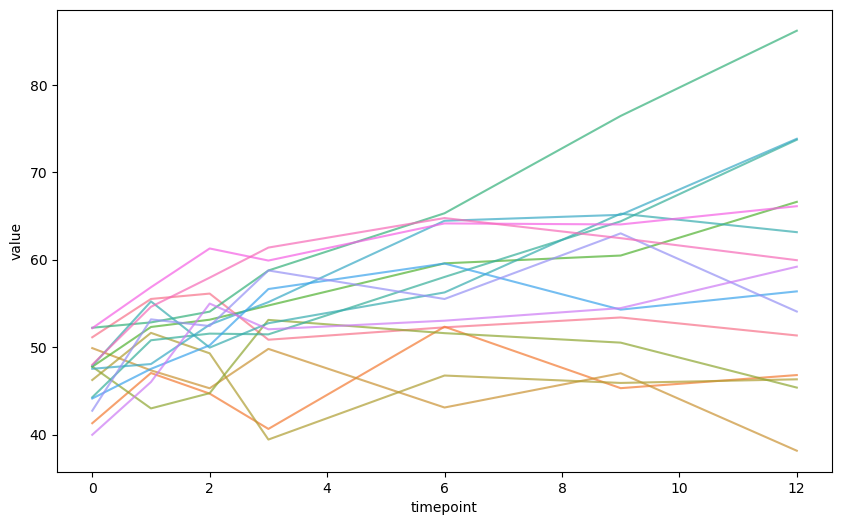

In [24]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='timepoint', y='value', hue='patient_id', legend=False, alpha=0.7)
plt.show()